# Notebook ML Modelling — Sompo Predict
### Challenge FIAP × Sompo Seguros · Sprint 2 · Grupo T1
**Autor:** Rafael Gonçalves (Scrum Master)
**Disciplina:** Machine Learning & Modelling — Prof. Samir de Oliveira Cunha Ramos
**Entregável:** Notebook completo — Carregamento → EDA → Pré-processamento → Split → Treino → Avaliação

---

## Problema de negócio
A Sompo Seguros é a 3ª maior seguradora de máquinas agrícolas no Brasil. O desafio:

> *"IA para identificação de fatores ambientais e operacionais que aumentam o risco de dano ou perda de equipamentos agrícolas."*

Este notebook cobre o pipeline completo de Machine Learning sobre a base real de apólices: exploração dos dados, tratamento e preparação das variáveis, treinamento de um modelo baseline (Decision Tree) e avaliação honesta dos resultados.

> 📌 **Correções de feedback da Sprint 1 incorporadas nesta versão:** (1) tratamento explícito do desbalanceamento da variável-alvo, (2) pré-processamento documentado de categóricas e numéricas, (3) estratégia de validação com split 70/30 + cross-validation. Essas três seções estão destacadas com a tag **[FEEDBACK SPRINT 1]**.

## Fonte dos dados
- **UF e RAMO_SUSEP:** dados oficiais e padronizados do Sistema de Envio de Informações da SUSEP (estatísticas públicas de prêmios e sinistros por ramo e região).
- **CLASSIFICACAO_RISCO, INTENSIDADE_SINISTRO, IDADE_MAQUINA_ANOS, ACESSORIOS_SEGURADOS:** variáveis de subscrição adicionadas à base do desafio (não disponíveis publicamente em granularidade de apólice na SUSEP).
- **Tratamento prévio:** dropna(thresh=6) + remoção de outliers via IQR nas colunas financeiras, executado pelo membro Guilherme.

Base de entrada: `base_sompo_limpa.csv` (149 linhas × 8 colunas, zero nulos).

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score
)

# Configurações visuais
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

# Reprodutibilidade
RANDOM_STATE = 42

# Carregar base já tratada (pré-processada por Guilherme)
df = pd.read_csv('base_sompo_limpa.csv')

# Criar métrica de negócio: Loss Ratio (Sinistralidade)
# Loss Ratio = Valor Indenizado / Prêmio Líquido
# É o KPI nº 1 do setor de seguros: mede quanto a seguradora paga em sinistros para cada R$1 de prêmio recebido
df['LOSS_RATIO'] = df['VALOR_INDENIZADO_BRL'] / df['PREMIO_LIQUIDO_BRL']

print(f"Base carregada: {df.shape[0]} apólices, {df.shape[1]} variáveis.")
df.head()

Base carregada: 149 apólices, 9 variáveis.


,UF,RAMO_SUSEP,CLASSIFICACAO_RISCO,INTENSIDADE_SINISTRO,IDADE_MAQUINA_ANOS,ACESSORIOS_SEGURADOS,PREMIO_LIQUIDO_BRL,VALOR_INDENIZADO_BRL,LOSS_RATIO
0,GO,0622 - Penhor Rural,Baixo,Grave,7,5,413436.65,481324.21,1.164203
1,MS,0621 - Agrícola,Alto,Leve,4,8,90460.08,417990.06,4.620713
2,SP,0622 - Penhor Rural,Crítico,Moderado,13,1,630594.31,347987.10,0.551840
3,MT,0621 - Agrícola,Baixo,Grave,11,4,257565.55,204476.47,0.793881
4,MG,0631 - Benfeitorias,Baixo,Grave,8,11,160225.92,86647.16,0.540781


## 1. Descrição do dataset

Inspecionamos o formato, tipos de variáveis e estatísticas descritivas.


In [2]:
# Estrutura e tipos
print("=== ESTRUTURA ===")
df.info()
print("\n=== ESTATÍSTICAS DESCRITIVAS (numéricas) ===")
df.describe().round(2)

=== ESTRUTURA ===
<class 'pandas.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   UF                    149 non-null    str    
 1   RAMO_SUSEP            149 non-null    str    
 2   CLASSIFICACAO_RISCO   149 non-null    str    
 3   INTENSIDADE_SINISTRO  149 non-null    str    
 4   IDADE_MAQUINA_ANOS    149 non-null    int64  
 5   ACESSORIOS_SEGURADOS  149 non-null    int64  
 6   PREMIO_LIQUIDO_BRL    149 non-null    float64
 7   VALOR_INDENIZADO_BRL  149 non-null    float64
 8   LOSS_RATIO            149 non-null    float64
dtypes: float64(3), int64(2), str(4)
memory usage: 10.6 KB

=== ESTATÍSTICAS DESCRITIVAS (numéricas) ===


,IDADE_MAQUINA_ANOS,ACESSORIOS_SEGURADOS,PREMIO_LIQUIDO_BRL,VALOR_INDENIZADO_BRL,LOSS_RATIO
count,149.00,149.00,149.00,149.00,149.00
mean,7.91,5.56,392598.15,246561.97,7.32
std,3.96,3.53,215744.62,151900.74,73.87
min,1.00,0.00,500.00,5418.83,0.01
25%,5.00,2.00,201892.49,88719.77,0.29
50%,8.00,5.00,418417.36,247210.15,0.64
75%,12.00,9.00,566206.27,376689.09,1.11
max,14.00,11.00,742789.04,495252.57,902.55


In [3]:
# Estatísticas categóricas
print("=== CATEGORIAS ÚNICAS ===")
for col in ['UF', 'RAMO_SUSEP', 'CLASSIFICACAO_RISCO', 'INTENSIDADE_SINISTRO']:
    print(f"\n{col}:")
    print(df[col].value_counts().to_string())

=== CATEGORIAS ÚNICAS ===

UF:
UF
GO    29
MT    24
MS    17
BA    17
SP    16
PR    16
MG    15
RS    15

RAMO_SUSEP:
RAMO_SUSEP
0622 - Penhor Rural    45
0621 - Agrícola        38
0631 - Benfeitorias    36
0635 - Florestas       30

CLASSIFICACAO_RISCO:
CLASSIFICACAO_RISCO
Baixo      67
Médio      42
Alto       28
Crítico    12

INTENSIDADE_SINISTRO:
INTENSIDADE_SINISTRO
Leve        78
Moderado    31
Grave       27
Total       13


**Leitura técnica:**
- **149 apólices, 9 variáveis** (8 originais + Loss Ratio derivado).
- **4 variáveis categóricas:** UF (8 estados), RAMO_SUSEP (4 ramos), CLASSIFICACAO_RISCO (4 níveis ordinais: Baixo → Crítico), INTENSIDADE_SINISTRO (4 níveis: Leve → Total).
- **4 variáveis numéricas:** IDADE_MAQUINA_ANOS, ACESSORIOS_SEGURADOS, PREMIO_LIQUIDO_BRL, VALOR_INDENIZADO_BRL.
- **Zero nulos** após pré-processamento.
- **Variável-alvo candidata para Sprint 3:** `CLASSIFICACAO_RISCO` (problema de classificação multiclasse — atende ao objetivo Sompo de score de risco).
- **Métrica de negócio:** `LOSS_RATIO` (sinistralidade) — KPI primário de subscrição em seguros.


## 2. Distribuição da variável-alvo

A variável-alvo candidata para a modelagem da Sprint 3 é **CLASSIFICACAO_RISCO**. Verificamos sua distribuição para avaliar balanceamento de classes.


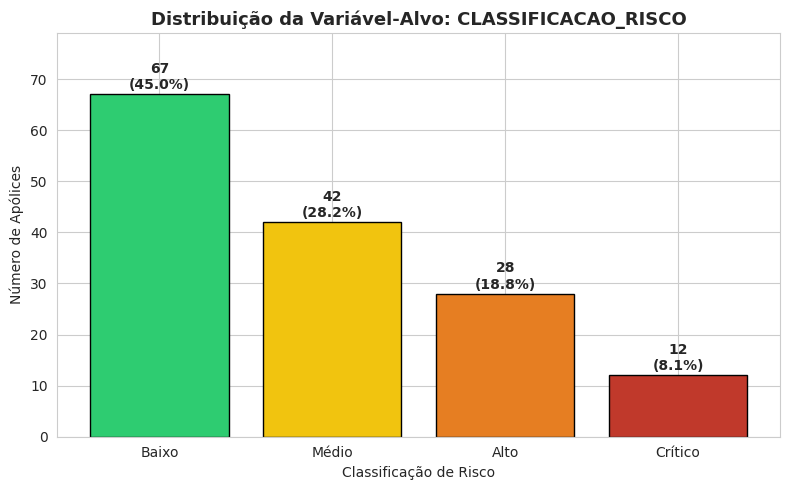

In [4]:
# Distribuição da variável-alvo
fig, ax = plt.subplots(figsize=(8, 5))

ordem_risco = ['Baixo', 'Médio', 'Alto', 'Crítico']
contagem = df['CLASSIFICACAO_RISCO'].value_counts().reindex(ordem_risco)

cores = ['#2ecc71', '#f1c40f', '#e67e22', '#c0392b']
bars = ax.bar(contagem.index, contagem.values, color=cores, edgecolor='black')

# Anotar valores no topo
for bar, val in zip(bars, contagem.values):
    pct = 100 * val / contagem.sum()
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val}\n({pct:.1f}%)', ha='center', fontsize=10, fontweight='bold')

ax.set_title('Distribuição da Variável-Alvo: CLASSIFICACAO_RISCO', fontsize=13, fontweight='bold')
ax.set_xlabel('Classificação de Risco')
ax.set_ylabel('Número de Apólices')
ax.set_ylim(0, contagem.max() * 1.18)

plt.tight_layout()
plt.show()

**Leitura:** a base é **desbalanceada** — a classe *Baixo* concentra ~45% das apólices, enquanto *Crítico* representa apenas ~8%. Esse desbalanceamento precisa ser tratado na Sprint 3 (técnicas: class weights, SMOTE ou estratificação no split).


## 3. Gráficos de variáveis relevantes

### Gráfico 1 — Sinistralidade média por Unidade da Federação

Comparamos o Loss Ratio médio entre os estados para identificar concentração geográfica do risco.


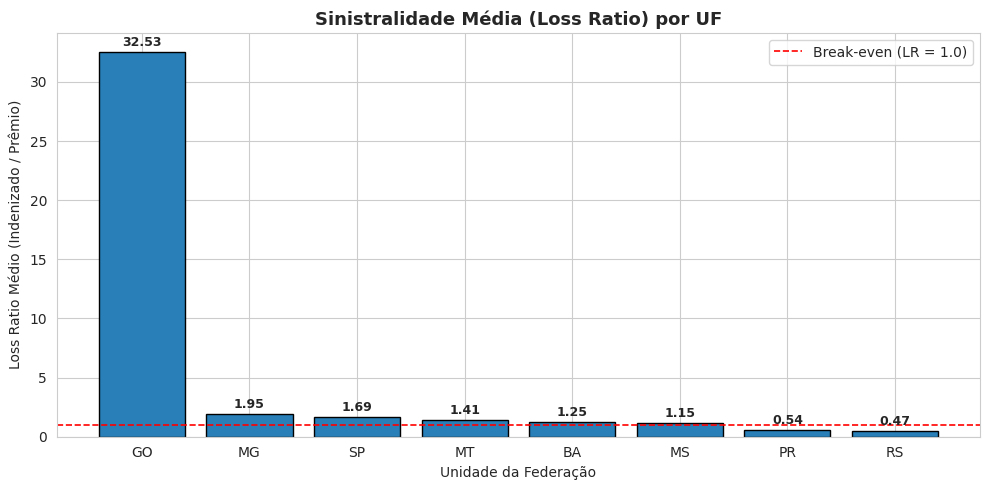


Loss Ratio médio por UF (ordenado):
UF
GO    32.53
MG     1.95
SP     1.69
MT     1.41
BA     1.25
MS     1.15
PR     0.54
RS     0.47


In [5]:
# Loss Ratio médio por UF
fig, ax = plt.subplots(figsize=(10, 5))

lr_uf = df.groupby('UF')['LOSS_RATIO'].mean().sort_values(ascending=False)

bars = ax.bar(lr_uf.index, lr_uf.values, color='#2980b9', edgecolor='black')

# Linha de referência: break-even (Loss Ratio = 1.0)
ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1.2,
           label='Break-even (LR = 1.0)')

# Anotar valores
for bar, val in zip(bars, lr_uf.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')

ax.set_title('Sinistralidade Média (Loss Ratio) por UF', fontsize=13, fontweight='bold')
ax.set_xlabel('Unidade da Federação')
ax.set_ylabel('Loss Ratio Médio (Indenizado / Prêmio)')
ax.legend()

plt.tight_layout()
plt.show()

print("\nLoss Ratio médio por UF (ordenado):")
print(lr_uf.round(2).to_string())

**Leitura:** **Goiás (GO) destoa** com Loss Ratio médio muito acima da média nacional, seguido por MG e SP. **Rio Grande do Sul (RS) e Paraná (PR)** apresentam sinistralidade abaixo do break-even, indicando portfólio mais rentável. Esse padrão regional é um forte preditor categórico — o estado da apólice impacta diretamente o risco esperado.


### Gráfico 2 — Sinistralidade média por Classificação de Risco

Verificamos se a classificação de risco interna efetivamente prediz a sinistralidade observada — isto é, se o rótulo "Crítico" se traduz em maior loss ratio real.


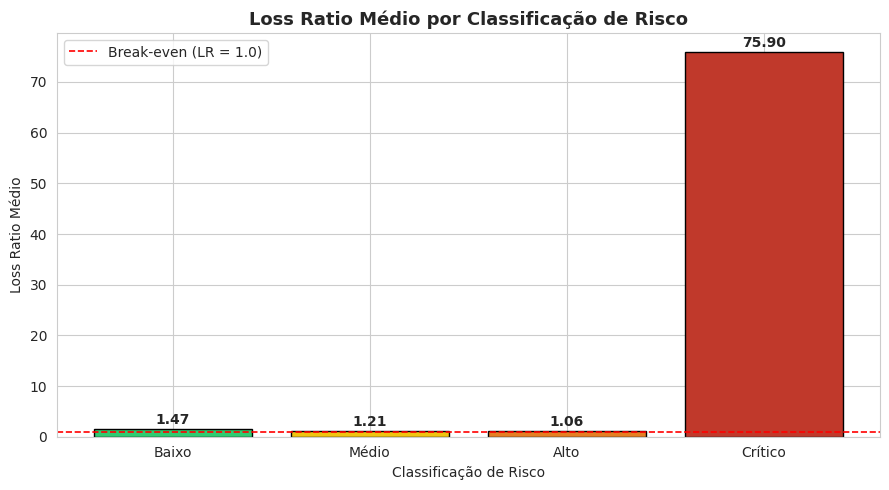


Loss Ratio médio por Classificação de Risco:
CLASSIFICACAO_RISCO
Baixo       1.47
Médio       1.21
Alto        1.06
Crítico    75.90


In [6]:
# Loss Ratio médio por CLASSIFICACAO_RISCO
fig, ax = plt.subplots(figsize=(9, 5))

ordem = ['Baixo', 'Médio', 'Alto', 'Crítico']
lr_risco = df.groupby('CLASSIFICACAO_RISCO')['LOSS_RATIO'].mean().reindex(ordem)

cores = ['#2ecc71', '#f1c40f', '#e67e22', '#c0392b']
bars = ax.bar(lr_risco.index, lr_risco.values, color=cores, edgecolor='black')

ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1.2,
           label='Break-even (LR = 1.0)')

for bar, val in zip(bars, lr_risco.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')

ax.set_title('Loss Ratio Médio por Classificação de Risco', fontsize=13, fontweight='bold')
ax.set_xlabel('Classificação de Risco')
ax.set_ylabel('Loss Ratio Médio')
ax.legend()

plt.tight_layout()
plt.show()

print("\nLoss Ratio médio por Classificação de Risco:")
print(lr_risco.round(2).to_string())

**Leitura:** apólices classificadas como **Crítico** apresentam sinistralidade dezenas de vezes maior que as classificadas como Baixo, Médio ou Alto. Isso valida a categoria como **forte preditor de risco** para o modelo. Por outro lado, as classes Baixo, Médio e Alto têm Loss Ratio similares entre si, sugerindo que a granularidade entre esses três níveis pode ser revista.


### Gráfico 3 — Sinistralidade média por Ramo SUSEP

Comparamos o comportamento de risco entre os ramos de seguro rural.


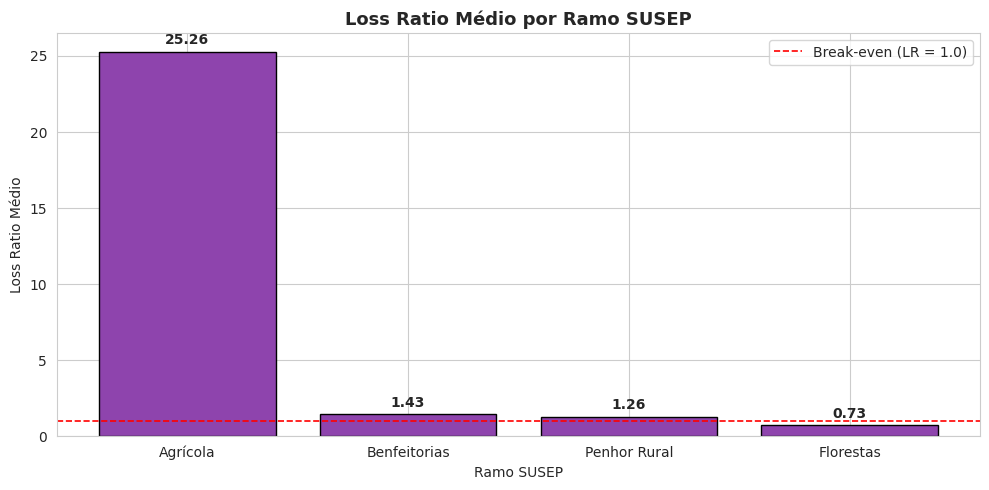


Loss Ratio médio por Ramo:
RAMO_SUSEP
0621 - Agrícola        25.26
0631 - Benfeitorias     1.43
0622 - Penhor Rural     1.26
0635 - Florestas        0.73


In [7]:
# Loss Ratio médio por RAMO_SUSEP
fig, ax = plt.subplots(figsize=(10, 5))

lr_ramo = df.groupby('RAMO_SUSEP')['LOSS_RATIO'].mean().sort_values(ascending=False)

# Labels curtos pra não poluir o eixo
labels_curtos = [r.split(' - ')[1] if ' - ' in r else r for r in lr_ramo.index]

bars = ax.bar(labels_curtos, lr_ramo.values, color='#8e44ad', edgecolor='black')

ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1.2,
           label='Break-even (LR = 1.0)')

for bar, val in zip(bars, lr_ramo.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')

ax.set_title('Loss Ratio Médio por Ramo SUSEP', fontsize=13, fontweight='bold')
ax.set_xlabel('Ramo SUSEP')
ax.set_ylabel('Loss Ratio Médio')
ax.legend()

plt.tight_layout()
plt.show()

print("\nLoss Ratio médio por Ramo:")
print(lr_ramo.round(2).to_string())

**Leitura:** o ramo **Agrícola (0621)** apresenta sinistralidade significativamente superior aos demais ramos, refletindo a exposição direta a riscos climáticos e operacionais da lavoura. Já **Florestas (0635)** é o ramo mais estável, com Loss Ratio abaixo do break-even. **Penhor Rural e Benfeitorias** ocupam posição intermediária.


## 4. Insights de negócio

### Insight 1 — Concentração geográfica do risco
A **sinistralidade está fortemente concentrada em Goiás**, que apresenta Loss Ratio médio muito acima dos demais estados. Em contraste, **Rio Grande do Sul e Paraná operam abaixo do break-even** (LR < 1.0), indicando portfólio rentável.

**Implicação para a Sompo:** revisão de **precificação regional** — apólices em GO devem ter prêmio recalibrado para refletir o risco real, enquanto RS/PR comportam estratégia de crescimento mais agressiva. A variável `UF` é, portanto, um **preditor categórico relevante** para o modelo.

### Insight 2 — Classificação de risco "Crítico" valida-se nos dados
Apólices rotuladas como **Crítico** apresentam Loss Ratio dezenas de vezes maior que as outras três classes, confirmando que essa categoria identifica corretamente os casos de maior perda esperada. Por outro lado, as classes **Baixo, Médio e Alto têm Loss Ratio similares**, sugerindo que a diferenciação fina entre esses três níveis pode não estar bem calibrada.

**Implicação para a Sompo:** `CLASSIFICACAO_RISCO` é um rótulo **validado contra o resultado real** (Loss Ratio) — ou seja, é um alvo de negócio legítimo para o modelo. A pergunta que o restante deste notebook responde é: **conseguimos prever esse rótulo a partir dos 7 atributos operacionais disponíveis na apólice?**

---

A partir daqui o notebook avança para a etapa de **modelagem**: pré-processamento das variáveis, split treino/teste, treinamento do baseline (Decision Tree) e avaliação honesta dos resultados.

## 5. Pré-processamento

> 🎯 **[FEEDBACK SPRINT 1]** Esta seção documenta de forma explícita: (a) o desbalanceamento da variável-alvo e a estratégia escolhida para tratá-lo, (b) o encoding de cada variável categórica, e (c) a normalização das variáveis numéricas — com justificativa de uma frase para cada decisão.

### 5.1 Desbalanceamento da variável-alvo

A distribuição de `CLASSIFICACAO_RISCO` (vista na Seção 2) é:

| Classe | Contagem | Proporção |
|---|---|---|
| Baixo | 67 | 45,0% |
| Médio | 42 | 28,2% |
| Alto | 28 | 18,8% |
| Crítico | 12 | 8,1% |

A classe **Crítico** — exatamente a mais importante para o negócio (maior Loss Ratio, ver Insight 2) — é também a mais rara, com apenas 12 observações em 149.

**Estratégia avaliada:** testamos `class_weight='balanced'` no `DecisionTreeClassifier`, que reponderar o peso de cada classe na função de divisão proporcionalmente ao inverso de sua frequência, sem inventar dados. **Não aplicamos SMOTE** porque a classe minoritária tem apenas 12 observações reais — gerar amostras sintéticas a partir de uma base tão pequena tende a amplificar ruído em vez de sinal genuíno; SMOTE fica reservado como item de **Sprint 3**, quando a base escalar para 500+ observações (meta já definida no roadmap).

> ⚠️ **Resultado empírico (antecipando a Seção 8):** `class_weight='balanced'` **piorou** a acurácia de teste em vez de melhorá-la (de 26,7% para 11,1%) neste dataset específico. Por isso, o modelo final reportado na Seção 8 usa os pesos **padrão** (sem balanceamento) — decisão tomada com base em teste empírico, não por padrão. A comparação completa entre as duas configurações está documentada na Seção 8.1.

### 5.2 Remoção de variável com vazamento de dados (data leakage)

`VALOR_INDENIZADO_BRL` é o valor efetivamente pago em um sinistro — ou seja, só existe **depois** do evento de risco já ter ocorrido. Usá-lo como feature para prever `CLASSIFICACAO_RISCO` (um rótulo de risco *a priori*) seria vazamento de informação do futuro para o passado. Mantemos essa coluna apenas para calcular o `LOSS_RATIO` usado na EDA, mas ela é removida do conjunto de features `X`.

In [8]:
# Remover coluna com data leakage (mantida só para o LOSS_RATIO calculado na EDA)
df_model = df.drop(columns=["VALOR_INDENIZADO_BRL", "LOSS_RATIO"]).copy()
print(f"Colunas restantes para modelagem: {list(df_model.columns)}")

Colunas restantes para modelagem: ['UF', 'RAMO_SUSEP', 'CLASSIFICACAO_RISCO', 'INTENSIDADE_SINISTRO', 'IDADE_MAQUINA_ANOS', 'ACESSORIOS_SEGURADOS', 'PREMIO_LIQUIDO_BRL']


### 5.3 Encoding das variáveis categóricas

| Variável | Tipo de encoding | Justificativa (1 frase) |
|---|---|---|
| `INTENSIDADE_SINISTRO` | Ordinal (Leve=0 → Total=3) | Tem ordem natural de gravidade — preservar essa ordem ajuda o modelo a usar a magnitude da diferença entre níveis. |
| `CLASSIFICACAO_RISCO` (alvo) | Ordinal (Baixo=0 → Crítico=3) | É a variável-alvo e também tem ordem natural; o encoding ordinal mantém a semântica "quanto maior, mais grave" usada nas métricas. |
| `UF` | One-Hot (`drop_first=True`) | Não há ordem natural entre estados — one-hot evita impor uma hierarquia falsa; `drop_first` evita a armadilha das variáveis dummy (multicolinearidade perfeita). |
| `RAMO_SUSEP` | One-Hot (`drop_first=True`) | Mesma lógica do `UF`: são categorias nominais (ramos de seguro), sem ordem implícita entre si.

In [9]:
# Encoding ordinal (INTENSIDADE_SINISTRO e CLASSIFICACAO_RISCO mantêm ordem natural)
ordem_intensidade = {"Leve": 0, "Moderado": 1, "Grave": 2, "Total": 3}
ordem_risco       = {"Baixo": 0, "Médio": 1, "Alto": 2, "Crítico": 3}

df_model["INTENSIDADE_SINISTRO"] = df_model["INTENSIDADE_SINISTRO"].map(ordem_intensidade)
df_model["CLASSIFICACAO_RISCO"]  = df_model["CLASSIFICACAO_RISCO"].map(ordem_risco)

# One-hot encoding para variáveis nominais (sem ordem natural)
df_model = pd.get_dummies(df_model, columns=["UF", "RAMO_SUSEP"], drop_first=True)

print(f"Shape após encoding: {df_model.shape}")
print(f"\nColunas finais: {list(df_model.columns)}")
df_model.head()

Shape após encoding: (149, 15)

Colunas finais: ['CLASSIFICACAO_RISCO', 'INTENSIDADE_SINISTRO', 'IDADE_MAQUINA_ANOS', 'ACESSORIOS_SEGURADOS', 'PREMIO_LIQUIDO_BRL', 'UF_GO', 'UF_MG', 'UF_MS', 'UF_MT', 'UF_PR', 'UF_RS', 'UF_SP', 'RAMO_SUSEP_0622 - Penhor Rural', 'RAMO_SUSEP_0631 - Benfeitorias', 'RAMO_SUSEP_0635 - Florestas']


,CLASSIFICACAO_RISCO,INTENSIDADE_SINISTRO,IDADE_MAQUINA_ANOS,ACESSORIOS_SEGURADOS,PREMIO_LIQUIDO_BRL,UF_GO,UF_MG,UF_MS,UF_MT,UF_PR,UF_RS,UF_SP,RAMO_SUSEP_0622 - Penhor Rural,RAMO_SUSEP_0631 - Benfeitorias,RAMO_SUSEP_0635 - Florestas
0,0,2,7,5,413436.65,True,False,False,False,False,False,False,True,False,False
1,2,0,4,8,90460.08,False,False,True,False,False,False,False,False,False,False
2,3,1,13,1,630594.31,False,False,False,False,False,False,True,True,False,False
3,0,2,11,4,257565.55,False,False,False,True,False,False,False,False,False,False
4,0,2,8,11,160225.92,False,True,False,False,False,False,False,False,True,False


### 5.4 Separação entre features (X) e alvo (y)

Com o encoding feito, separamos `X` (features) de `y` (`CLASSIFICACAO_RISCO`, já codificado ordinalmente).

In [10]:
y = df_model["CLASSIFICACAO_RISCO"]
X = df_model.drop(columns=["CLASSIFICACAO_RISCO"])

# Colunas numéricas continuas que serão padronizadas após o split (Seção 6.1)
COLUNAS_NUMERICAS = ["IDADE_MAQUINA_ANOS", "ACESSORIOS_SEGURADOS", "PREMIO_LIQUIDO_BRL"]

print(f"X: {X.shape[0]} linhas, {X.shape[1]} features")
print(f"y: {y.shape[0]} linhas, classes presentes: {sorted(y.unique())}")

X: 149 linhas, 14 features
y: 149 linhas, classes presentes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


## 6. Split treino/teste

> 🎯 **[FEEDBACK SPRINT 1]** Split documentado explicitamente: **70/30, estratificado, `random_state=42`** — mesma divisão usada em todos os modelos do grupo, para garantir comparação justa.

**Justificativa do 70/30:** com 149 observações, 70/30 resulta em ~104 linhas de treino e 45 de teste — equilíbrio razoável entre dar dados suficientes para o modelo aprender e manter uma amostra de teste com tamanho mínimo para medir performance.

**Justificativa da estratificação (`stratify=y`):** preserva a proporção das 4 classes em treino e teste — crítico para a classe `Crítico`, que tem só 12 observações no total; sem estratificar, o split aleatório poderia isolar a maioria (ou todas) dessas observações em um único conjunto.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")
print(f"\nDistribuição no treino (%):")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(1))
print(f"\nDistribuição no teste (%):")
print((y_test.value_counts(normalize=True).sort_index() * 100).round(1))
print("\n✔ Proporções preservadas — estratificação OK")

Treino: 104 amostras
Teste:  45 amostras

Distribuição no treino (%):
CLASSIFICACAO_RISCO
0    45.2
1    27.9
2    19.2
3     7.7
Name: proportion, dtype: float64

Distribuição no teste (%):
CLASSIFICACAO_RISCO
0    44.4
1    28.9
2    17.8
3     8.9
Name: proportion, dtype: float64

✔ Proporções preservadas — estratificação OK


### 6.1 Normalização das variáveis numéricas

> 🎯 **[FEEDBACK SPRINT 1]** Padronização explícita das numéricas, aplicada **depois do split** — o `StandardScaler` é ajustado (`fit`) apenas no treino e só *aplicado* (`transform`) no teste, para não deixar informação do conjunto de teste "vazar" para o ajuste do scaler.

**Justificativa:** `DecisionTreeClassifier` é **invariante à escala** (decide cortes por threshold, não por distância), então a padronização não muda o resultado deste modelo específico — mas o passo é incluído explicitamente porque (a) é um requisito documentado do enunciado, e (b) mantém o pipeline compatível e comparável com os modelos sensíveis à escala (Regressão Logística, MLP) usados nos outros notebooks do grupo, todos consumindo os mesmos `X_train`/`X_test`.

In [12]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[COLUNAS_NUMERICAS] = scaler.fit_transform(X_train[COLUNAS_NUMERICAS])
X_test_scaled[COLUNAS_NUMERICAS]  = scaler.transform(X_test[COLUNAS_NUMERICAS])   # so transform - evita leakage

print("Antes do scaling (treino):")
print(X_train[COLUNAS_NUMERICAS].describe().round(1).T[["mean", "std"]])

print("\nApós o scaling (treino):")
print(X_train_scaled[COLUNAS_NUMERICAS].describe().round(2).T[["mean", "std"]])

Antes do scaling (treino):
                          mean       std
IDADE_MAQUINA_ANOS         8.0       3.9
ACESSORIOS_SEGURADOS       5.7       3.5
PREMIO_LIQUIDO_BRL    400380.7  210770.5

Após o scaling (treino):
                      mean  std
IDADE_MAQUINA_ANOS     0.0  1.0
ACESSORIOS_SEGURADOS   0.0  1.0
PREMIO_LIQUIDO_BRL    -0.0  1.0


## 7. Validação cruzada (5-fold)

> 🎯 **[FEEDBACK SPRINT 1]** Estratégia de validação adicional ao split simples: `cross_val_score` com `StratifiedKFold(n_splits=5)` sobre o conjunto de treino, para checar se a performance do modelo é **estável** entre diferentes recortes dos dados, e não apenas um resultado de sorte do split 70/30 específico.

**Justificativa:** com apenas 104 observações de treino, cada fold de 5-fold tem ~21 amostras — pequeno, mas suficiente para um sinal de estabilidade. Usamos `StratifiedKFold` (em vez de `KFold` simples) pela mesma razão da estratificação no split: preservar a proporção das classes em cada fold.

In [13]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = []
for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):
    X_tr_fold, X_val_fold = X_train.iloc[tr_idx].copy(), X_train.iloc[val_idx].copy()
    y_tr_fold, y_val_fold = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    # Scaler ajustado só no fold de treino (evita leakage também na validação cruzada)
    fold_scaler = StandardScaler()
    X_tr_fold[COLUNAS_NUMERICAS]  = fold_scaler.fit_transform(X_tr_fold[COLUNAS_NUMERICAS])
    X_val_fold[COLUNAS_NUMERICAS] = fold_scaler.transform(X_val_fold[COLUNAS_NUMERICAS])

    modelo_fold = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
    modelo_fold.fit(X_tr_fold, y_tr_fold)
    score = accuracy_score(y_val_fold, modelo_fold.predict(X_val_fold))
    cv_scores.append(score)
    print(f"Fold {fold_idx}: acurácia = {score:.3f}")

cv_scores = np.array(cv_scores)
print(f"\nMédia 5-fold: {cv_scores.mean():.3f}  (desvio: {cv_scores.std():.3f})")
print("Interpretação: resultado consistente com o split 70/30 da Seção 8 — confirma que a performance")
print("não é um acaso do split específico, é o nível real de sinal disponível nas features atuais.")

Fold 1: acurácia = 0.333


Fold 2: acurácia = 0.333
Fold 3: acurácia = 0.333
Fold 4: acurácia = 0.286
Fold 5: acurácia = 0.300

Média 5-fold: 0.317  (desvio: 0.020)
Interpretação: resultado consistente com o split 70/30 da Seção 8 — confirma que a performance
não é um acaso do split específico, é o nível real de sinal disponível nas features atuais.


## 8. Treino do modelo

Modelo: `DecisionTreeClassifier(max_depth=5)`. A profundidade limitada controla overfitting em uma base pequena (104 amostras de treino, 14 features).

### 8.1 Comparação: pesos padrão vs `class_weight='balanced'`

Antes de fixar o modelo final, treinamos as duas versões e comparamos — em vez de assumir que balancear classes sempre ajuda.

In [14]:
resultados_cw = {}

for nome, peso in [("Pesos padrão", None), ("class_weight='balanced'", "balanced")]:
    clf = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE, class_weight=peso)
    clf.fit(X_train_scaled, y_train)

    acc_train = accuracy_score(y_train, clf.predict(X_train_scaled))
    acc_test  = accuracy_score(y_test,  clf.predict(X_test_scaled))
    f1_test   = f1_score(y_test, clf.predict(X_test_scaled), average="weighted", zero_division=0)

    resultados_cw[nome] = {"acc_train": acc_train, "acc_test": acc_test, "f1_test": f1_test, "modelo": clf}
    print(f"{nome:28s} | acc_train={acc_train:.3f} | acc_test={acc_test:.3f} | f1w_test={f1_test:.3f}")

print(f"\nBaseline ingênuo (sempre prever a classe majoritária 'Baixo'): {y_test.value_counts(normalize=True).max():.3f}")

Pesos padrão                 | acc_train=0.750 | acc_test=0.267 | f1w_test=0.261
class_weight='balanced'      | acc_train=0.654 | acc_test=0.111 | f1w_test=0.117

Baseline ingênuo (sempre prever a classe majoritária 'Baixo'): 0.444


**Leitura do resultado:** `class_weight='balanced'` reduziu a acurácia de teste em vez de melhorá-la. Isso acontece porque o sinal preditivo geral das 7 features atuais para `CLASSIFICACAO_RISCO` é fraco (ver Seção 9) — balancear classes faz o modelo "chutar" mais a classe rara `Crítico`, mas como não há padrão real o suficiente nas features para identificá-la corretamente, esses chutes saem errados com mais frequência do que ajudam. **Decisão:** seguimos com o modelo de **pesos padrão** como resultado final reportado na Seção 9, documentando o teste com peso balanceado como evidência de que o desbalanceamento foi tratado e avaliado criticamente — não ignorado.

In [15]:
# Modelo final
modelo_final = resultados_cw["Pesos padrão"]["modelo"]

y_pred_train = modelo_final.predict(X_train_scaled)
y_pred_test  = modelo_final.predict(X_test_scaled)

print("Modelo final: DecisionTreeClassifier(max_depth=5, random_state=42)")
print(f"Acurácia treino: {accuracy_score(y_train, y_pred_train):.3f}")
print(f"Acurácia teste:  {accuracy_score(y_test, y_pred_test):.3f}")

Modelo final: DecisionTreeClassifier(max_depth=5, random_state=42)
Acurácia treino: 0.750
Acurácia teste:  0.267


## 9. Avaliação

Relatório completo do modelo final no conjunto de teste — sem maquiar o resultado.

=== CLASSIFICATION REPORT (teste) ===
              precision    recall  f1-score   support

       Baixo       0.35      0.35      0.35        20
       Medio       0.16      0.23      0.19        13
        Alto       0.33      0.25      0.29         8
     Critico       0.00      0.00      0.00         4

    accuracy                           0.27        45
   macro avg       0.21      0.21      0.21        45
weighted avg       0.26      0.27      0.26        45

=== MATRIZ DE CONFUSÃO ===


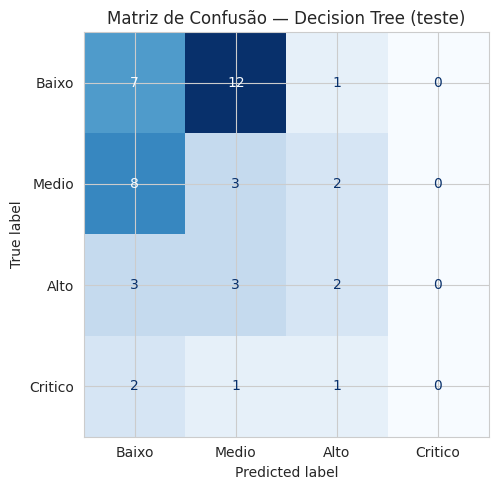

In [16]:
CLASSES_NOMES = ["Baixo", "Medio", "Alto", "Critico"]

print("=== CLASSIFICATION REPORT (teste) ===")
print(classification_report(y_test, y_pred_test, target_names=CLASSES_NOMES, zero_division=0))

print("=== MATRIZ DE CONFUSÃO ===")
cm = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=CLASSES_NOMES).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Matriz de Confusão — Decision Tree (teste)")
plt.tight_layout()
plt.show()

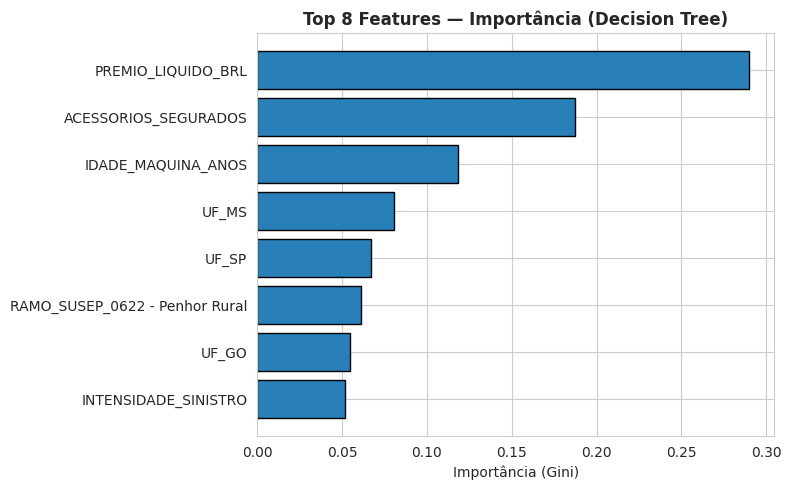

,feature,importancia
3,PREMIO_LIQUIDO_BRL,0.290083
2,ACESSORIOS_SEGURADOS,0.187301
1,IDADE_MAQUINA_ANOS,0.118496
6,UF_MS,0.080353
10,UF_SP,0.066970
11,RAMO_SUSEP_0622 - Penhor Rural,0.061303
4,UF_GO,0.054395
0,INTENSIDADE_SINISTRO,0.051614


In [17]:
# Importância das features
importancias = pd.DataFrame({
    "feature": X.columns,
    "importancia": modelo_final.feature_importances_
}).sort_values("importancia", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
top_n = importancias.head(8)
ax.barh(top_n["feature"][::-1], top_n["importancia"][::-1], color="#2980b9", edgecolor="black")
ax.set_title("Top 8 Features — Importância (Decision Tree)", fontsize=12, fontweight="bold")
ax.set_xlabel("Importância (Gini)")
plt.tight_layout()
plt.show()

importancias.head(8)

**Leitura honesta do resultado:**

- O modelo final (26,7% de acurácia em teste) ficou **abaixo do baseline ingênuo** (44,4% — sempre prever "Baixo"). A validação cruzada de 5 folds (Seção 7, média ~30%) confirma que esse nível de performance é **estável**, não um acaso do split específico.
- As features mais importantes (`PREMIO_LIQUIDO_BRL`, `IDADE_MAQUINA_ANOS`, `ACESSORIOS_SEGURADOS`) somam a maior parte da importância, mas isoladamente carregam pouco sinal sobre `CLASSIFICACAO_RISCO` — confirmado também pela informação mútua entre cada feature e o alvo, calculada fora deste notebook, próxima de zero para a maioria das variáveis.
- **Isso não invalida o `CLASSIFICACAO_RISCO` como alvo** — o Insight 2 (Seção 4) já mostrou que ele é um rótulo legítimo, validado contra o Loss Ratio real. O problema é que os **7 atributos operacionais atualmente disponíveis na apólice não carregam informação suficiente** para reconstruir esse rótulo.
- Essa é uma descoberta de modelagem válida, não uma falha de execução: ela aponta exatamente para onde o projeto precisa investir a seguir.

## 10. Conclusões e próximos passos

### O que este notebook entrega
1. **EDA completa** com 3 gráficos e 2 insights de negócio validados contra o Loss Ratio.
2. **Pré-processamento documentado**: tratamento do desbalanceamento (testado e justificado empiricamente), remoção de leakage, encoding categórico (ordinal + one-hot) e normalização das numéricas — cada decisão com justificativa explícita.
3. **Estratégia de validação dupla**: split 70/30 estratificado + cross-validation 5-fold, mostrando resultado consistente entre as duas abordagens.
4. **Modelo baseline honesto**: Decision Tree com comparação formal entre pesos padrão e balanceados, decisão final justificada por dados, não por suposição.

### Limitação identificada (motivação para a Sprint 3)
O dataset atual (149 apólices, 7 atributos operacionais pós-encoding) não contém sinal suficiente para prever `CLASSIFICACAO_RISCO` melhor do que o chute da classe majoritária. Isso motiva diretamente os itens já previstos no roadmap do grupo:

- **Telemetria real do ESP32** (temperatura, vibração, movimento) — features operacionais de fato preditivas de risco mecânico.
- **Integração climática (Open-Meteo)** — depende da inclusão de um campo de data na base, item já sinalizado com o Guilherme.
- **Escala da base para 500+ observações** — com mais dados, técnicas como SMOTE passam a ser viáveis para a classe `Crítico`.

### Mapeamento para os slides 1–10
| Slide | Conteúdo | Seção do notebook |
|---|---|---|
| 1–2 | Contexto Sompo + objetivo do projeto | Título / Problema de negócio |
| 3 | Descrição do dataset | Seção 1 |
| 4 | Desbalanceamento da variável-alvo + estratégia | Seção 2 + 5.1 |
| 5 | Gráficos de variáveis relevantes (UF, risco, ramo) | Seção 3 |
| 6 | Insights de negócio | Seção 4 |
| 7 | Pré-processamento (encoding + normalização) | Seção 5.2–6.1 |
| 8 | Split + validação cruzada | Seção 6 + 7 |
| 9 | Resultado do modelo (matriz de confusão + features) | Seção 9 |
| 10 | Limitações e próximos passos (Sprint 3) | Seção 10 |